# <font color=firebrick>Econometrics — M2 MBFA</font>
## Session 1 / 8 (CM) — Why OLS? The Model & a Monte Carlo Simulation

**Prerequisites:** none — this is the first session of the course.

**TodayS's objectives:**
- Understand *why* we use the OLS (Ordinary Least Squares) method to summarize a relationship between variables.
- Write a simple linear model and its matrix notation.
- Use a **Monte Carlo simulation** to generate our own data from a *known* Data-Generating Process (DGP), so that we can later check whether OLS recovers the true parameter.

Practice exercises for this session are provided in the companion TD notebook.

---


## 1. Why OLS? ([top](#home)) <a id="math"></a>

To begin understanding econometrics, let’s frame a typical problem economists face: describing and quantifying the relationship between variables using data from $N$ observations.

Suppose we are interested in a particular outcome, or *dependent variable* we’ll call $y$. For each individual (or firm, country, day, etc.) in our dataset, we also observe several other factors that may help explain $y$. These are called *explanatory variables* (or regressors) and we denote the $p$ variables by:

$$x_{1}, x_{2}, \dots, x_{p}.$$

For example, suppose an economist wants to predict future movements in a stock market index, like the S&P 500. For each day $i$, they may observe interest rates, inflation, and other economic indicators. These variables form a vector of explanatory variables

$$\mathbf{x}_i = (x_{1i}, x_{2i}, \dots, x_{pi})$$


and the corresponding outcome $y_i$ is the value of the index that day.

The econometric model links $y_i$ to the vector $\mathbf{x}_i$, that is to $x_{1i}, \dots, x_{pi}$. This approach not only enables predictions of $y$ but also interpretation, giving insights into *how* and *why* changes in economic factors influence the S\&P 500.

### From a single observation to the whole dataset

In econometrics, we assume that each observation $i = 1, \dots, N$ the outcome $y_i$ is related to the explanatory variables through a model of the form:
$$
y_i = f(\mathbf{x_i}) + \varepsilon_i = f(x_{1i}, x_{2i}, \dots, x_{pi}) + \varepsilon_i,
$$
where:

- $y_i$ is the value of the dependent variable for observation $i$,
- $x_{1i}, \dots, x_{pi}$ are the values of the $p$ explanatory variables for observation $i$,
- $f(\cdot)$ is the systematic or structural part of the relationship between the explanatory variables and $y_i$,
- $\varepsilon_i$ is the *error term* (or *noise*) capturing all factors affecting $y_i$ that are not included in $\mathbf{x}_i$.


**Why the error term matters**

It is worth taking a moment to consider $\varepsilon_i$, because it is truly at the very heart of what “modeling” means, even though it may seem like an element added as an afterthought at the end of the equation.

Building a model always supposes making a *simplification*: starting from an extremely complex reality, we choose a bunch of variables $x_{1i}, \dots, x_{pi}$ that, in our view, reflect the essential mechanism underlying $y_i$. These few variables can potentially explain a *very large* portion of the behavior of $y_i$—but we can never be sure that they explain *all* of it, and in practice, they never do. There will always be something left out: factors we did not measure, did not think of, mismeasured, or that are simply unpredictable.

$\varepsilon_i$ is precisely what lets the equation stay *correct* despite this simplification. Writing
$$
y_i = f(x_{1i}, \dots, x_{pi}) + \varepsilon_i
$$
rather than the false exact equality $y_i = f(x_{1i}, \dots, x_{pi})$ means we are not pretending that a few chosen variables explain $y_i$ perfectly. Whatever "small" (or sometimes not so small) difference remains between the real, observed $y_i$ and what our simplified model predicts is captured by $\varepsilon_i$.

Modeling well is therefore not just about choosing good explanatory variables - it is also about being explicit and careful about what we assume on this remaining difference. Most of what we do in the rest of this course (unbiasedness, variance, the t-test...) is really about understanding and controlling this error term.

This equation is meant to hold **for each observation in the dataset**.

### Matrix notation
It is often useful to write the $N$ equations at once using matrix notation:

$$
\mathbf{y} =
\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_N \end{pmatrix}, \quad
\mathbf{X} =
\begin{pmatrix}
x_{11} & x_{12} & \dots & x_{1p} \\
x_{21} & x_{22} & \dots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{N1} & x_{N2} & \dots & x_{Np}
\end{pmatrix}, \quad 
\boldsymbol{\varepsilon} =
\begin{pmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_N \end{pmatrix}.
$$

In this form, the model for all observations can be written compactly as
$$
\boxed{
\mathbf{y} = f(\mathbf{X}) + \mathbf{\varepsilon}.}
$$

where:
- The vector $\mathbf{y}$ is a $ N \times 1 $ vector of observed values,
- The matrix $ \mathbf{X} $ is a $ N \times p $ matrix of explanatory variables, with each row corresponding to an observation.
- The vector $ \boldsymbol{\epsilon} $ is the $ N \times 1 $ vector of error terms for each observation.

This model just means that for each row $i$, the model $y_i = f(x_{1i}, \dots, x_{pi}) + \varepsilon_i$ holds. 

### <font color='teal'>Quick check #1</font>

**1. What best describes the role of the error term $\varepsilon_i$?**

a) It is a measurement mistake that a good model should always eliminate.<br>
b) It captures everything affecting $y_i$ that our chosen explanatory variables do not.<br>
c) It is set to zero by assumption, so we can ignore it in practice.<br>
d) It only matters when $N$ is small.

<details>
<summary>Show answer</summary>

Answer: **b)**. The error term is not a mistake to eliminate - it is the formal, honest acknowledgment that a handful of explanatory variables can never capture $y_i$ perfectly.

</details>

**2. Why do we only include a handful of explanatory variables $x_{1i}, \dots, x_{pi}$ rather than "everything" that could possibly affect $y_i$?**

a) Because Python cannot handle regressions with more than a few variables.<br>
b) Because modeling means simplifying reality to a manageable, interpretable set of factors, even though this necessarily leaves some influences out.<br>
c) Because economic theory forbids using more than a handful of variables.<br>
d) Because using more variables always causes bugs in `statsmodels`.

<details>
<summary>Show answer</summary>

Answer: **b)**. Any model is a deliberate simplification. What is left out of $\mathbf{x}_i$ does not vanish - it is exactly what $\varepsilon_i$ represents.

</details>

**3. In the equation $y_i = f(x_{1i}, \dots, x_{pi}) + \varepsilon_i$, the function $f(\cdot)$ represents:**

a) A physical law that is always known exactly.<br>
b) Our chosen hypothesis about how the explanatory variables combine to explain $y_i$.<br>
c) The part of $y_i$ we agree to ignore.<br>
d) A constant term only.

<details>
<summary>Show answer</summary>

Answer: **b)**. Choosing $f$ is a modeling decision made *before* estimation - it encodes our belief about *how* $\mathbf{x}_i$ affects $y_i$, not just whether it does.

</details>

---


# 2. The model

Now that we have introduced the general idea:
$$
\mathbf{y} = f(\mathbf{X}) + \mathbf{\varepsilon},
$$

we need to be more precise: what is $f$ and which variables go into $\mathbf{X}$?

**What is $f(\cdot)$?**

$f(\cdot)$ is simply our *hypothesis* about how the explanatory variables combine to produce $y_i$ - it is not something we observe in the data, but something we choose. In principle $f$ could take almost any shape: a straight line, a curve, a step function, an interaction between two variables, etc. Choosing $f$ is therefore already a modeling decision, made *before* we start estimating anything: it reflects what we believe - from economic theory, intuition, or previous studies - about *how* $x_{1i}, \dots, x_{pi}$ affect $y_i$, not just *whether* they do. Getting $f$ wrong can lead to misleading conclusions even if the data themselves are perfect. This is why, below, we start from the simplest and most transparent choice for $f$: a linear function.

In econometrics, the choice of the explanatory variables and the functional form of $f$ is guided by:
- the research question (what we want to explain or predict?),
- economic theory and previous empirical work,
- and the data that are actually available.

### Example: advertising and online sales

Suppose we want to study how online advertising spending on a social media platform affects e-commerce sales. The dependent variable $y_i$ could be monthly sales for month $i$.

The explanatory variables $\mathbf{x}_i = (x_{1i}, x_{2i}, \dots, x_{pi})$ might include advertising expenditures, website traffic, customer demographics, seasonal dummies, etc. If our goal is to estimate the causal effect of advertising, we must make sure that advertising expenditure is included in $\mathbf{X}$ and that other important variables that affect sales (and are related to advertising) are also controlled for, to avoid biased estimates. Once we specify the variables, we still need to choose the functional form $f$.

Moreover, our model should allow us to interpret results meaningfully, such as estimating the advertising elasticity of demand. Understanding this relationship helps in decision-making, like optimizing digital marketing strategies.

### Choosing a linear model

We start with a linear model. Linear regression is widely used because:
- it is simple and interpretable,
- coefficients have a clear meaning (“if $x_k$ increases by 1 unit, $y$ changes by $\beta_k$ units on average”),
- many more complex models can be approximated locally by a linear model.

**Linear in the parameters, not necessarily in the variables**

A common misunderstanding is to think a "linear model" can only describe straight-line relationships. What "linear" really means here is *linear in the parameters* $\beta_1, \dots, \beta_p$: each explanatory variable enters the equation multiplied by a single coefficient, and these terms are simply added together. The variables $x_{1i}, \dots, x_{pi}$ themselves can already be transformations of the raw data - for example $\log(x_i)$, $x_i^2$, or an interaction $x_{1i}\times x_{2i}$ - and the model is still "linear" in the econometric sense, because it stays linear in the $\beta$'s. This distinction matters: the simple linear framework introduced here is far more flexible than it first looks, and in Session 3 we will use exactly this trick (logs, interactions) to capture curvature or more complex relationships without ever leaving the OLS framework.

**Why restricting to linear is not too restrictive**

This connects to a deeper mathematical fact: under fairly general conditions, (almost) any reasonably well-behaved function can be written - or closely approximated - as a linear combination of simpler, known basis functions. A **Taylor expansion** approximates a function using powers $1, x, x^2, x^3, \dots$; a **Fourier expansion** approximates a (periodic) function using sines and cosines $\cos(x), \sin(x), \cos(2x), \sin(2x), \dots$. In both cases the function itself is a *linear combination* of these basis functions, even though the basis functions themselves are not linear. This is exactly the logic used just above: if we suspect $f$ is not linear in $x_i$, we can often still capture it within our linear-regression toolbox by adding transformed regressors ($x_i^2$, $\log(x_i)$, $\sin(x_i)$, ...) as new explanatory variables and letting OLS estimate the coefficient attached to each of them. This is one of the main reasons the linear model, despite looking simple, is used so extensively in practice.

Formally, we assume that for each observation:
$$
y_i =  \beta_1 x_{1i} +  \beta_2 x_{2i} + \cdots + \beta_p x_{pi} + \mathbf{\varepsilon_i}.
$$


### Matrix notation

For all $N$ observations, we define:

$$
\mathbf{y} =
\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_N \end{pmatrix}, \quad
\mathbf{X} =
\begin{pmatrix}
x_{11} & x_{12} & \dots & x_{1p} \\
x_{21} & x_{22} & \dots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{N1} & x_{N2} & \dots & x_{Np}
\end{pmatrix}, \quad 
\beta =
\begin{pmatrix} \beta_1 \\ \beta_2 \\ \vdots \\ \beta_p \end{pmatrix},
\quad 
\boldsymbol{\varepsilon} =
\begin{pmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_N \end{pmatrix}.
$$


The linear model for the whole dataset can then be written as:
$$
\boxed{
\mathbf{y} = \mathbf{X}\beta + \mathbf{\varepsilon}.}
$$

This allows us to easily find each individual equation from the matrix form:
$$
y_j = \beta_1 X_{1i} + \beta_2 X_{2i} + \cdots + \beta_p X_{pi} +\varepsilon_j, \quad i = 1, \dots, N.
$$

### A simpler example

To build intuition, let’s go back to a very simple case with one explanatory variable: advertising spending only. We now assume that monthly sales depend only on advertising expenditures. Our model with $N$ observations is:
$$
y_j = \beta X_{i} +\varepsilon_i, \quad i = 1, \dots, N.
$$

where:

- $y_i$ are the sales in month $i$,
- $x_i$ is the advertising expenditure in month $i$,
- $\beta$ is the (unknown) effect of advertising on sales,
- $\varepsilon_i$ includes all other factors affecting sales in month $i$ that are not captured by $x_i$.

This equation reflects that sales $ y_i $ for each month $ i $ depend on advertising spend $ x_i $ scaled by the coefficient $ \beta $ and a random error $ \varepsilon_i $ capturing other factors affecting sales. 

In matrix notation, this becomes:
$$
\mathbf{y} =
\begin{pmatrix} y_1 \\ \vdots \\ y_N \end{pmatrix}, \quad
\mathbf{X} =
\begin{pmatrix} x_1 \\ \vdots \\ x_N \end{pmatrix}, \quad 
\beta = \begin{pmatrix}  \beta \end{pmatrix},\quad 
\mathbf{\varepsilon} = \begin{pmatrix} \varepsilon_1 \\ \vdots \\ \varepsilon_N \end{pmatrix}.
$$

It means that we still have:
$$
\mathbf{y} = \mathbf{X}\beta + \mathbf{\varepsilon}.
$$

By estimating $ \beta $, we can answer questions like: How much does an additional dollar spent on advertising increase monthly sales? This provides actionable insights for businesses looking to optimize their advertising budgets. We learn to answer to such questions in the next section using Ordinary Least Squares (OLS).

### <font color='teal'>Quick check #2</font>

**1. Consider the model $y_i = \beta_1 \log(x_{1i}) + \beta_2 x_{2i}^2 + \varepsilon_i$. Is this a "linear model" in the econometric sense?**

a) No, because $x_{1i}$ appears inside a log and $x_{2i}$ is squared.<br>
b) Yes, because it is linear in the parameters $\beta_1, \beta_2$, even though the variables themselves are transformed.<br>
c) Only if $x_{1i}$ and $x_{2i}$ are both positive.<br>
d) No - only $y=\beta_0+\beta_1 x$ counts as linear.

<details>
<summary>Show answer</summary>

Answer: **b)**. "Linear" refers to linearity in the parameters $\beta$, not in the raw variables. $\log(x_{1i})$ and $x_{2i}^2$ can simply be treated as new regressors.

</details>

**2. In the matrix notation $\mathbf{y}=\mathbf{X}\beta+\varepsilon$, with $N=200$ observations and $p=4$ explanatory variables (excluding the constant), what are the dimensions of $\mathbf{X}$?**

a) $4\times 200$<br>
b) $200\times 4$<br>
c) $200\times 200$<br>
d) $4\times 4$

<details>
<summary>Show answer</summary>

Answer: **b)**. Each of the $N=200$ observations is a row, and each of the $p=4$ explanatory variables is a column, so $\mathbf{X}$ is $200\times 4$.

</details>

**3. Why can a linear regression framework still capture curved, non-linear-looking relationships between the raw variables?**

a) It cannot - that is a fundamental limitation of OLS.<br>
b) Because we can include transformed regressors (logs, squares, interactions...) while the model stays linear in $\beta$ - the same logic behind Taylor or Fourier expansions.<br>
c) Only by switching to a logit or probit model instead.<br>
d) By simply adding more observations $N$.

<details>
<summary>Show answer</summary>

Answer: **b)**. As with a Taylor or Fourier expansion, we can approximate a curved relationship with a linear combination of (possibly non-linear) basis functions of $x$.

</details>

---


# 3. Monte Carlo simulation

In general, for pedagogical reasons, we work with real data by assuming a functional form for $f$ and estimating the parameter $\beta$. This assumption is necessary to make the model fit the observed data as closely as possible. However, if the assumed form of $f$ is incorrect, the estimates of $\beta$ may be biased or inconsistent.

To overcome this uncertainty, we take a different approach here by generating our own data using a true Data-Generating Process (DGP). In this case, we know the exact value of $\beta$ and can directly evaluate how well our estimation method recovers it. This approach is called a Monte Carlo simulation and it allows us to test the performance and reliability of estimators under controlled conditions.


**Python code**

Execute the code below using "Shift+Enter". Explanations of the code are given below.

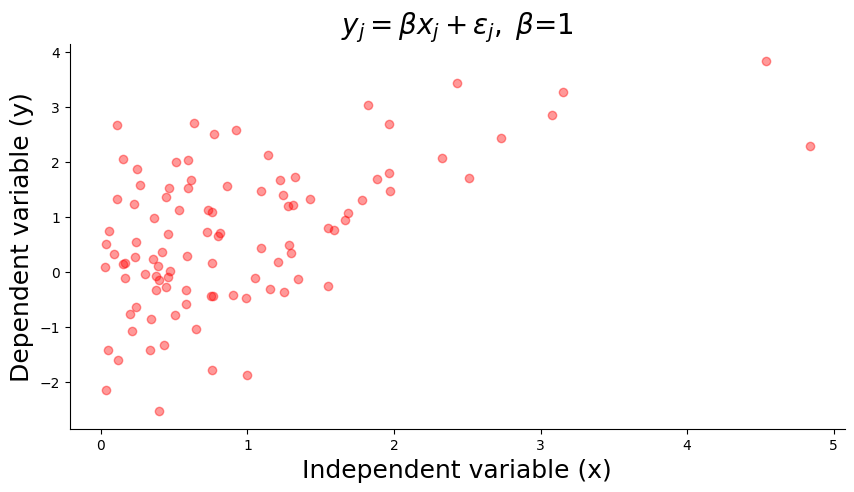

In [11]:
#Importing libraries
import numpy as np # Used for numerical operations (e.g., generating random numbers).
import matplotlib.pyplot as plt # Used for plotting graphs.
#import seaborn as sea # Data visualization library built on Matplotlib (not used in the code).
import pandas as pd # Used for data manipulation (not used in the code).


# Create a local random generator with a fixed seed to ensure the same "random" numbers are generated each time we run this code.
rng = np.random.default_rng(seed=10)

# Set values
beta = 1 # Coefficient for the independent variable X
N = 100 # Number of observations or data points

# Generate random N draws with an exponential distribution
x = rng.exponential(1,size=N)

# Generate random N draws with a normal distribution
eps = rng.normal(0,1,size=N)

# Determine Y
y = x * beta + eps

# Create Figure
fig, ax = plt.subplots(figsize=(10,5)) # Creates a figure and axis with specified size for the plot.

ax.scatter(x, y, alpha = 0.4, color='red') # Creates a scatter plot with X on the x-axis and Y on the y-axis, with some transparency (`alpha=0.4`) and red color for the points.

ax.set_xlabel('Independent variable (x)', size=18) # Set the labels and title for the plot.
ax.set_ylabel('Dependent variable (y)', size=18)
ax.set_title(r'$y_j = \beta x_j + \epsilon_j,\;\beta$=' + str(beta), size=20)

ax.spines['top'].set_visible(False) # Hide the top and right borders of the plot for a cleaner appearance.
ax.spines['right'].set_visible(False)

plt.show() # Displays the plot.

**Python code explanation**

1. **Setting the seed**:
   - `np.random.default_rng(seed=10)`: This sets the seed for the random number generator to ensure reproducibility. When the code is run multiple times, it generates the same "random" numbers.

2. **Generating random variables**:
   - `x = rng.exponential(1,size=N)`: Generates `N` random draws from an exponential distribution with a mean of 1. These are the values for the independent variable $x$.
   - `eps = rng.normal(0,1,size=N)`: Generates `N` random draws from a normal distribution with mean 0 and standard deviation 1. These are the error terms $\epsilon$.

4. **Calculating the dependent variable**:
   - `y = x * beta + eps`: The dependent variable $y$ is determined by the formula $y = \beta x + \epsilon$, where $\beta = 1$.

**Why do we fix a random seed?**

In simulations, random numbers are used to generate artificial data. If we don’t fix the random seed, the data will change every time we run the code — meaning the results will also change. By setting a seed with `np.random.default_rng(seed=10)`), we make sure that:
- the same random numbers are generated each time,
- results are reproducible,
- we can debug and compare models fairly.

This is especially important in econometrics and Monte Carlo simulations, where we want to see how models behave - not how random noise changes.

Next, to better understand how the code works, you can print the different variables generated by the code and view their contents:

In [8]:
print(rng)
print(x)

Generator(PCG64)
[0.77432097 0.46505417 1.88268974 0.44745569 3.150756   0.04844171
 1.31420099 0.22938735 0.75984671 0.59227638 0.58649068 0.2365351
 0.75232363 0.63466462 1.22185473 2.4316753  0.47196459 1.15423541
 0.10829897 0.37667554 0.92346295 1.96798627 0.24476518 1.66902182
 0.33856259 0.86022474 0.42053159 0.1651062  0.61827647 0.24187026
 0.21042522 1.04988487 0.6472637  1.55180902 0.50701077 0.20191585
 0.37684032 0.76627329 0.79676374 1.96274854 2.32633849 1.0926723
 1.29882682 0.08844127 1.32341287 0.44399692 1.24860687 0.39046329
 0.35437196 0.26839152 0.39520828 0.51043482 0.75630511 1.78019722
 1.09321227 0.45836055 4.53851426 3.07916828 0.59397634 0.30093416
 1.1393683  0.16815138 1.27417149 4.83500485 0.81367863 0.72897138
 0.90249049 1.28279557 1.21186193 0.1541197  0.57771739 0.58182752
 0.99493857 0.43342362 0.7226448  1.34291272 0.39625701 1.97013395
 1.42997527 0.02850114 1.23994118 2.51217196 0.11303563 1.55207802
 0.45907955 0.9898815  1.59187478 0.11478111 0.

In [9]:
print(eps)
print(fig, ax)

[ 1.73476660e+00  1.06500311e+00 -1.99447029e-01  9.16564686e-01
  1.17142392e-01 -1.48138308e+00 -1.06651506e-01  9.94687152e-01
 -5.96362768e-01  9.35990425e-01 -3.06682929e-01  2.64899548e-02
 -1.19114957e+00  2.07017858e+00  4.53437214e-01  1.00842980e+00
 -4.52709300e-01 -1.46340463e+00  1.21160857e+00 -7.11864631e-01
  1.65205247e+00 -1.71102173e-01  1.62453073e+00 -7.29026790e-01
 -1.76398883e+00  6.98090495e-01 -6.80487959e-02 -2.72066456e-03
  1.04870777e+00 -8.82152891e-01 -1.29463031e+00 -1.16843669e+00
 -1.68216663e+00 -1.80862211e+00 -1.28523894e+00 -9.74003652e-01
 -4.58935133e-01 -1.21436078e+00 -1.49666002e-01  7.31246901e-01
 -2.51739284e-01  3.79636984e-01 -9.57340905e-01  2.37145137e-01
  4.04136495e-01 -7.18203404e-01 -1.61524157e+00 -2.83124930e-01
 -1.17703114e-01  1.30197725e+00 -5.42570906e-01  1.48608868e+00
 -2.54075343e+00 -4.66922562e-01 -6.56815077e-01 -5.54662489e-01
 -7.07057893e-01 -2.32432483e-01  1.43935065e+00 -3.39981763e-01
  9.88025065e-01 -2.86514

### Link with matrix notation

The Python code generates synthetic data for the linear regression model:
$$
y_i = \beta x_i + \epsilon_i \quad \text{for } j = 1, \dots, N
$$
where:
- $ y_i $ is the dependent variable.
- $ x_o $ is the independent variable.
- $ \beta $ is the coefficient (set to 1 in this example).
- $ \epsilon_i $ is the random error term, drawn from a normal distribution $ \mathcal{N}(0, 1) $.



\begin{array}{|c|c|c|c|}
\hline
\textbf{Python Code} & \textbf{Matrix Notation} & \textbf{Python Object} & \textbf{Explanation} \\
\hline
x = rng.exponential(1,size=N) & x \sim \text{Exponential}(1) & \text{List of size } N & \text{Generate } x \\
\hline
\epsilon = rng.normal(0,1,size=N) & \epsilon \sim \mathcal{N}(0, 1) & \text{List of size } N & \text{Generate noise } \epsilon \\
\hline
y = \beta \cdot x + \epsilon & y = x \beta + \epsilon & \text{List of size } N & \text{Compute } y \\
\hline
\texttt{ax.scatter(y, x, ...)} & \text{Scatter plot} & \text{N/A} & \text{Visualize } x \text{ vs. } y \\
\hline
\texttt{ax.set\_title(...)} & y_i = \beta x_i + \epsilon_i, \; \beta = 1 & \text{N/A} & \text{Set plot title} \\
\hline
\end{array}




### Interpretation of the generated plot

The scatter plot shows the generated data points. The independent variable $ x $ (on the x-axis) has been drawn from an exponential distribution and the dependent variable $ y $ (on the y-axis) is a linear function of $  $ with added random noise $ \epsilon $.

This visualization demonstrates how randomness in $ \epsilon $ creates variation in $ y $, even when the relationship with $ x $ is linear.




**We present below the equivalent of this code in Stata and R.**

We present below the equivalents of this code for Stata and R. You are invited to click on the two texts below to discover the codes, read the explanations and test them in Stata and R. You can then compare these codes with the Python code. Note the similarities and differences between the three languages.

### Stata code

<details>
<summary>-- Click here to see the Stata code --</summary>

**Running code in Stata**

To run the code in **Stata** using Stata software, follow these steps:
1. **Open Stata**
2. **Type commands** in the Command Window
3. **Copy the code below** and paste it in the Command Window
4. **Press enter to execute** the code and display results.

You can also save this code in a **do-file** for later execution:
1. In Stata, go to File > New Do-file or use the Do-file Editor
2. Paste your code into the Do-file
3. Save the file (e.g., my_analysis.do)
4. Type: `do my_analysis.do` in the Command Window and press Enter to run the code

**Stata code** 
```Stata
set seed 10

* Set values
local beta 1
local N 100

* Generate random draws for x and eps
gen x = rexp(1) in 1/`N'
gen eps = rnormal(0,1) in 1/`N'

* Calculate y
gen y = `beta' * x + eps

* Scatter plot
twoway (scatter y x, mcolor(red) msymbol(O) msize(medium)) ///
       , xlabel(, size(18)) ylabel(, size(18)) title("$y_i = \beta x_i + \epsilon_i, \;\beta=" + string(`beta')) size(20)
```

**Stata code explanation**

- ``gen x = rexp(1) in 1/`N'``: Generates $N$ random draws from an exponential distribution.
- ``gen eps = rnormal(0,1) in 1/`N'``: Generates $N$ random draws from a normal distribution with mean 0 and standard deviation 1.
- ``twoway scatter`: Plots $y$ against $x$ with red circles as markers (``mcolor(red)`).
- The ``xlabel()``, ``ylabel()``, and ``title()`` options adjust the appearance of the plot, including the labels and title.
</details>



### R code

<details>
<summary>-- Click here to see the R code --</summary>



**Running code in R using RStudio**

To run the code in R using RStudio, follow these steps:
1. **Open RStudio**
2. **Open a new R script:** Go to File > New File > R Script or press Ctrl + Shift + N
3. **Copy-paste the R code** into the R script in the RStudio editor
4. **Run the code:** Highlight the code you want to run and press Ctrl + Enter (Windows/Linux) or Cmd + Enter (Mac)

Alternatively, you can click on the Run button at the top of the script editor to execute the entire script.

**R code** 
```R
# R code example
set.seed(10)

# Set values
beta <- 1
N <- 100

# Generate random draws for x and eps
x <- rexp(N, rate = 1)
eps <- rnorm(N, mean = 0, sd = 1)

# Calculate y
y <- beta * x + eps

# Create a scatter plot with equation in title
plot(x, y, col = "red", pch = 16, 
     xlab = "Independent Variable (x)", 
     ylab = "Dependent Variable (y)", 
     main = expression(paste("y[i] = ", beta, " * x[i] + epsilon[i], ", beta, " = ", 1)))
```


**R code explanation**

- ``x <- rexp(N, rate = 1)``: Generates N random draws from an exponential distribution.
- ``eps <- rnorm(N, mean = 0, sd = 1)``: Generates N random draws from a normal distribution.
- ``y <- beta * x + eps``: Calculates the dependent variable $y$.
- ``plot()``: Creates the scatter plot with red points (``col = "red"``), adjusted point size (``pch = 16``), axis labels, and the plot title that includes the value of $\beta$.

</details>

### <font color='orange'>Task #1:</font> Analyze the Impact of $\beta$ on the Data-Generating Process (DGP)

Modify the value of $\beta$ to 0.5, 2, and 5 in the code, and re-run the code for each value of $\beta$.

1. How does $\beta$ affect the slope of the relationship between $𝑋$ (independent variable) and $𝑌$ (dependent variable)?
2. Does increasing $\beta$ make the observations more spread out or closer together? Why?

<details>
<summary>-- Click here to see the answer --</summary>
    
1. **How does $\beta$ affect the slope?**

$\beta$ is the slope of the deterministic part of the Data-Generating Process (DGP). If we change $\beta$, we scale the systematic relationship between $x$ and $y$. A larger $\beta$ means a steeper slope, while a smaller $\beta$ means a flatter slope. Graphically, the regression line $y = \beta x$ rotates around the origin (in our simple model with no intercept).

2. **Does increasing $\beta$ make observations more spread out or closer?**

The variance of $y$ is (assuming $x$ and $\varepsilon$ are independent):

$$
Var(y)=Var(\beta x + \epsilon)= \beta^2 Var(x)+Var(\epsilon)
$$.

As $|\beta|$ increases, the term $\beta^2 Var (x)$ grows, so the total variance of $y$ increases — the observations become more spread out vertically. Intuitively, scaling the systematic part $\beta x$ stretches the cloud of points along the $y$-axis. The noise term $\varepsilon$ remains the same but its relative importance diminishes when $\beta$ is large.
    </details>

### <font color='teal'>Quick check #3</font>

**1. Why do we generate our own data from a known Data-Generating Process (Monte Carlo simulation) instead of immediately using real-world data?**

a) Real data is more expensive to obtain than simulated data.<br>
b) Because we know the true $\beta$ in a simulation, so we can directly check whether our estimation method recovers it.<br>
c) Because real data cannot be loaded into Python.<br>
d) Because simulated data has no error term.

<details>
<summary>Show answer</summary>

Answer: **b)**. With real data, the true $\beta$ is unknown, so we can never be fully sure an estimator "worked". Simulating our own DGP lets us test the method against a known answer.

</details>

**2. What is the purpose of fixing a random seed (e.g. `rng = np.random.default_rng(seed=10)`)?**

a) To force the model to estimate a specific value of $\beta$.<br>
b) To make sure the same "random" numbers are generated every time the code is run, so results are reproducible.<br>
c) To remove randomness from the error term $\varepsilon$.<br>
d) It is just a convention with no real effect.

<details>
<summary>Show answer</summary>

Answer: **b)**. Fixing the seed makes the simulation reproducible: everyone who runs the code gets the exact same "random" draws, and hence the exact same figures.

</details>

**3. In the DGP $y=\beta x+\varepsilon$, if you increase $\beta$ from 1 to 5 while keeping the same draws of $x$ and $\varepsilon$, what happens?**

a) Nothing changes.<br>
b) The systematic relationship becomes steeper, and the variation in $y$ coming from $x$ becomes large relative to the noise $\varepsilon$.<br>
c) The error term $\varepsilon$ disappears.<br>
d) $x$ becomes negative.

<details>
<summary>Show answer</summary>

Answer: **b)**. Recall from Task #1: $\text{Var}(y)=\beta^2\text{Var}(x)+\text{Var}(\varepsilon)$. A larger $\beta$ scales up the systematic part relative to the fixed noise.

</details>

---

### <font color='orange'>Task #2:</font> Find your own best-fitting line

**Part A - by hand.** Consider this tiny dataset (no need for Python here, just pen and paper):

| $x_i$ | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| $y_i$ | 2.1 | 3.9 | 6.2 | 7.8 | 10.1 |

For a candidate line $\hat y_i=\beta x_i$ through the origin, the residual is $\hat\varepsilon_i=y_i-\beta x_i$ and the total error is the **sum of squared residuals** $\text{SSR}(\beta)=\sum_i \hat\varepsilon_i^2$.

1. Compute $\text{SSR}(\beta)$ for $\beta=1.5$ and for $\beta=2$.
2. Which of the two candidate values fits the data better?

<details>
<summary>Show answer</summary>

For $\beta=1.5$: predicted values are $1.5, 3, 4.5, 6, 7.5$; residuals are $0.6, 0.9, 1.7, 1.8, 2.6$; $\text{SSR}(1.5)= 0.36+0.81+2.89+3.24+6.76=14.06$.

For $\beta=2$: predicted values are $2, 4, 6, 8, 10$; residuals are $0.1, -0.1, 0.2, -0.2, 0.1$; $\text{SSR}(2)=0.01+0.01+0.04+0.04+0.01=0.11$.

$\beta=2$ fits *much* better (a far smaller SSR) - unsurprising, since the data were built to closely follow $y_i\approx 2x_i$.
</details>

**Part B - on the computer.** Go back to the Monte Carlo data (`x`, `y`) generated earlier in this notebook. In the empty cell below:
1. Pick a candidate value `beta_guess` (try, e.g., 0.5, then 1, then 2).
2. Compute the predicted values `y_pred = beta_guess * x` and the sum of squared residuals `ssr = np.sum((y - y_pred)**2)`.
3. Make a scatter plot of the data together with your candidate line, and print the SSR in the title (you can reuse and adapt the plotting code from Section 3).
4. Try a few different values of `beta_guess`. Which one gives you the smallest SSR? How does it compare to the true $\beta$ used to generate the data?

We will see next session how to find the *exact* best value of $\beta$ analytically, rather than by trial and error.
